# Causal Identification

This notebook covers why correlations can mislead and how we can recover causal effects under appropriate assumptions. We move from an intuitive paradox to formal definitions, and conclude with practical estimation using adjustment.

> Beginning with a well-known phenomenon: **Simpson’s paradox**.

This occurs when a relationship observed in aggregated data reverses when we examine subgroups. In other words, the data appears to tell two contradictory stories depending on how we look at them. To illustrate this, we use a simple synthetic dataset with arbitrary units.

> Suppose we study the effect of a treatment (dosage) on recovery time. Intuition suggests that higher dosage should lead to faster recovery. However, patients differ in severity of illness. More severe cases tend to receive higher dosages, and also tend to recover more slowly. This creates the possibility that severity may distort the relationship we observe.

First, the severity is ignored and we look only at the overall relationship between dosage and recovery time.

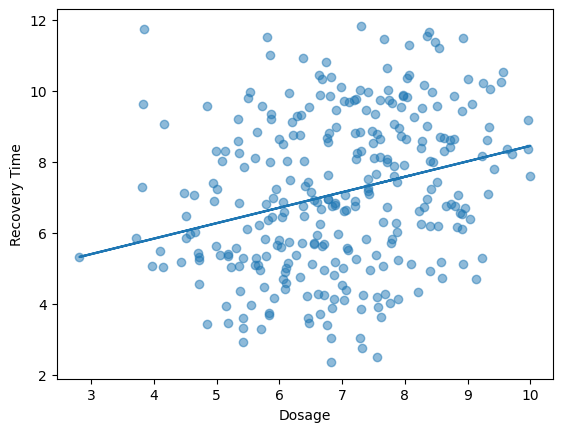

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import plot_reg

# Load dataset 
df = pd.read_csv("../data/data1.csv")

# Create a scatter plot of Dosage vs Recovery Time
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], alpha=0.5)

# Overlay a regression line
plot_reg(df)
plt.xlabel('Dosage')
plt.ylabel('Recovery Time')
plt.show()

If we were to rely on this plot alone, one might conclude that higher dosage is associated with longer recovery times. This conclusion is misleading because it ignores the severity, which is a crucial variable.

Patients with more severe conditions both receive higher dosages and tend to recover more slowly. This creates a spurious positive association in the aggregated data.

> To uncover the true relationship, we now examine each severity group separately.

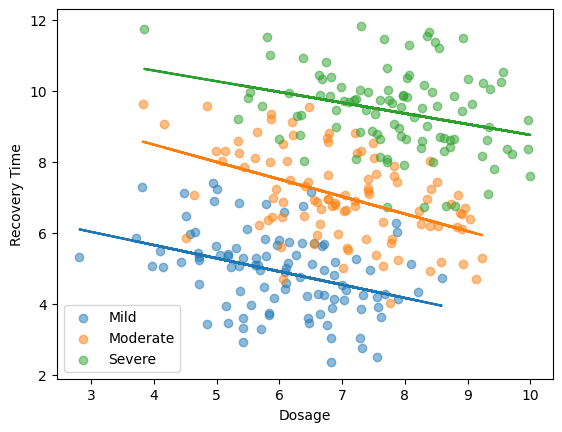

In [4]:
# Loop through each severity category
for severity in ['Mild', 'Moderate', 'Severe']:
    df_temp = df[df['severity'] == severity]

    # Overlay each scatter plot of Dosage vs Recovery Time
    plt.scatter(df_temp.iloc[:, 0], df_temp.iloc[:, 1], label=severity, alpha=0.5)

    # Overlay a regression line
    plot_reg(df_temp)

plt.xlabel('Dosage')
plt.ylabel('Recovery Time')
plt.legend()
plt.show()

 Within each severity group, the relationship reverses: higher dosage is associated with shorter recovery time. Thus, the aggregated data suggest one conclusion, while every subgroup suggests the opposite. This is **Simpson’s paradox**.

**Why this happens**

The paradox arises because severity is a confounder: it influences both the treatment (dosage) and the outcome (recovery time). When we ignore severity, we mix together fundamentally different populations, and the resulting correlation no longer reflects the causal effect of dosage.

> **Intervention vs conditioning**
>
> A core distinction in causal inference separates two superficially similar operations: *conditioning* on a variable and *intervening* on it. Both involve fixing a variable to some value, but they carry fundamentally different meanings.
>
> **Conditioning** (written $P(Y \mid T = t)$) asks: among units where we observed $T = t$, what is the distribution of $Y$? This is a purely associational statement and it says nothing about what would happen if we changed $T$.
>
> **Intervention** (written $P(Y \mid do(T = t))$) asks: if we were to forcibly set $T = t$ for every unit, regardless of any other factors, what would happen to $Y$? The $do(\cdot)$ operator, formalised by Pearl, represents a surgical modification to the data-generating process.

**The role of confounding**

In our example, severity influences both dosage and recovery time.

> We can represent the problem schematically:
>
> ![description](../figures/DAG1.png)

Severity acts as a confounder and opens a backdoor path between dosage and recovery time. This induces a spurious association that is not due to the causal effect of dosage. By conditioning on severity, we block this backdoor path and remove the confounding, allowing us to isolate the true causal effect of dosage.

**Unconfoundedness**

To recover causal effects from observational data, we require a critical assumption known as **unconfoundedness**.

Informally, this means that once we condition on the relevant variables, the treatment assignment is as good as random. In other words, all confounding has been accounted for by the variables we condition on.

> In notation, this is often written as:
>
> $
Y(0), Y(1) \perp T \mid C
> $

where $C$ represents the set of variables we condition on. Under this assumption, any remaining association between treatment and outcome can be interpreted causally.

> To see why this assumption is powerful, we now turn to a classic illustration: the Berkeley admissions data from 1979, where aggregated statistics suggest one conclusion, but conditioning reveals a very different story.


In [5]:
# URL pointing to the dataset containing university admissions or major-related data
url = "https://waf.cs.illinois.edu/discovery/berkeley.csv"
df = pd.read_csv(url)

# Remove rows where the "Major" column is labelled as 'Other'
# This helps focus the dataset on specific academic majors rather than miscellaneous categories
df = df[df["Major"] != 'Other']

The Berkeley admissions data (1979) records graduate school applications across several departments, along with admission outcomes broken down by gender. At first glance, the aggregated figures appear to suggest a clear difference in admission rates between men and women.

The aim of this example is to show how such a conclusion can be misleading when important structure is ignored. Once we condition on department, the apparent effect changes substantially, illustrating how confounding can reverse naive interpretations of observational data.

> We introduce the **potential outcomes** view of causality.
>
> For each individual, we imagine two possible outcomes:
>
> * $Y(1)$: the outcome if the individual is male
> * $Y(0)$: the outcome if the individual is female


Rather than asking whether admission rates differ by gender in the observed data, we now ask: $\newline$
*How would the admission outcome differ if the applicant belonged to one gender group rather than the other?*

> In the potential outcomes framework, this corresponds to the comparison between two hypothetical outcomes:
>
> > $
> > Y(1) - Y(0)
> > $

In reality, we only ever observe one of these for each individual. The other remains counterfactual.
>
> This is known as the **fundamental problem of causal inference**:
>
> > We cannot observe both potential outcomes for the same individual at the same time.

This framework shifts the problem from modelling correlations to reasoning about hypothetical interventions.


> **Average treatment effect (ATE)**
>
> Since individual-level causal effects cannot be observed, we instead focus on the **average treatment effect**:
>
> > $
> > \text{ATE} = \mathbb{E}[Y(1) - Y(0)]
> > $

This represents the expected difference in outcomes between the two groups at the population level. 

In [14]:
import numpy as np

df["Gender"] = df["Sex"].map({"M": "Men", "F": "Women"})

# 1 if admitted ("Accepted"), 0 otherwise
df["rate"] = (df["Admission"] == "Accepted").astype(int)

# Compute admission rates by grouping over Major and Gender
rates = df.pivot_table(
    index="Major",
    columns="Gender",
    values="rate",
    aggfunc="mean"
)


print(rates)

# Compute overall admission rates for each gender
overall = df.groupby("Gender")["rate"].mean()

print()
print(overall.to_string())
print()

print(f"Naive associational difference (Men - Women): {overall['Men'] - overall['Women']:.3f}")

Gender       Men     Women
Major                     
A       0.724956  0.824074
B       0.630357  0.680000
C       0.369231  0.338954
D       0.330935  0.349333
E       0.277487  0.239186
F       0.058981  0.073314

Gender
Men      0.502996
Women    0.303542

Naive associational difference (Men - Women): 0.199


The naive estimate suggests that men have an admission advantage of 0,199.

However, this comparison ignores the role of department. Since application patterns differ by department and departments have different admission rates, this estimate mixes together within-department effects with differences in department composition.

As a result, it does not represent a causal effect.

> **The identification problem**
>
> We cannot directly compute the ATE because we never observe both potential outcomes for the same individual.
>
> Instead, we observe:
>
> * Outcomes for individuals in group $T=1$
> * Outcomes for individuals in group $T=0$
>
The challenge is therefore to relate these observed quantities to the causal effect of interest. This is where assumptions such as unconfoundedness become essential.


> **Identification via adjustment**
>
> Under the assumption of unconfoundedness, we can express the causal effect using observed data.
>
> Conditioning on a confounder $C$ (here, department), the ATE can be written as:
>
> $
> \mathbb{E}[Y(1) - Y(0)] = \sum_c \left( \mathbb{E}[Y \mid T=1, C=c] - \mathbb{E}[Y \mid T=0, C=c] \right) P(C=c)
> $
>
> This is known as the **adjustment formula**.

It shows that we can recover causal effects by comparing outcomes within levels of the confounder, and then averaging across the population. From a graphical perspective, this corresponds to the **backdoor adjustment**: conditioning on C blocks all non-causal (backdoor) paths between treatment and outcome.

In [21]:
# Compute the marginal distribution of majors
major_weights = df["Major"].value_counts(normalize=True)

# Compute conditional admission rates:
# P(Admission = Accepted | Major, Gender)
major_gender_rates = df.pivot_table(
    index="Major",
    columns="Gender",
    values="rate",
    aggfunc="mean"
)

print(major_gender_rates)
print("-" * 60)

# Weighted average over majors
adjusted = (major_gender_rates.mul(major_weights, axis=0)).sum()

# Compute naive overall admission rates by gender
overall = df.groupby("Gender")["rate"].mean()

print(f"Overall admission rate (Men):   {overall['Men']:.3f}")
print(f"Overall admission rate (Women): {overall['Women']:.3f}")
print(f"Naive difference (Men - Women): {overall['Men'] - overall['Women']:.3f}")
print("-" * 60)


print(f"Adjusted admission rate (Men):      {adjusted['Men']:.3f}")
print(f"Adjusted admission rate (Women):    {adjusted['Women']:.3f}")
print(f"Adjusted difference (Men - Women): {adjusted['Men'] - adjusted['Women']:.3f}")

Gender       Men     Women
Major                     
A       0.724956  0.824074
B       0.630357  0.680000
C       0.369231  0.338954
D       0.330935  0.349333
E       0.277487  0.239186
F       0.058981  0.073314
------------------------------------------------------------
Overall admission rate (Men):   0.503
Overall admission rate (Women): 0.304
Naive difference (Men - Women): 0.199
------------------------------------------------------------
Adjusted admission rate (Men):      0.429
Adjusted admission rate (Women):    0.456
Adjusted difference (Men - Women): -0.026


After adjusting for department, the estimated effect changes substantially. The apparent advantage observed in the aggregate data was driven by differences in department composition rather than a direct effect. This again illustrates a central lesson: $\newline$
*Correlation alone is not sufficient to identify causal relationships.*

To recover causal effects, we must account for variables that distort the relationship between treatment and outcome. This leads to the central question of causal inference: $\newline$
*Under what conditions can we recover the effect of a treatment from observational data?*

> **An untestable assumption**
>
> A subtle but important point is that unconfoundedness cannot be verified from the data alone. The reason is fundamental: we never observe both potential outcomes for the same individual. As a result, we cannot directly check whether all relevant confounders have been accounted for.
>
> Causal inference from observational data therefore relies on domain knowledge, judgement, and assumptions that extend beyond the observed dataset.
